# The Solow Growth Model

**Table of contents**<a id='toc0_'></a>    
- [1. The Standard Solow Model](#toc1_)    
  - [1.1. Analytical Solution](#toc1_1_)    
  - [1.2. Numerical Solution](#toc1_2_)    
  - [1.3. Analysis - Simulation and Comparative Analysis](#toc1_3_)  
      - [1.3.1. Different Initial Levels of Capital](#toc1_3_1_)  
      - [1.3.2. Different Savings Rates](#toc1_3_2_)  
      - [1.3.3. A Shock to Technology](#toc1_3_3_)  
- [2. Extensions of the Model](#toc2_)
  - [2.1. The Solow Model with Endogenous Technological Progress](#toc2_1_)  
      - [2.1.1. Analytical Solution](#toc2_1_1_)  
      - [2.1.2. Numerical Solution](#toc2_1_2_)  
      - [2.1.3. Simulation of the Solow model with technological progress](#toc2_1_3_)  
      - [2.1.4. Different Initial Levels of Capital](#toc2_1_4_)  
      - [2.1.5 Different Savings Rates](#toc2_1_5_)  
      - [2.1.6. A Shock to Technology](#toc2_1_6_)    
  - [2.2. The Solow Model with Human Capital](#toc2_1_)
      - [2.2.1. Analytical Solution](#toc2_2_1_)  
      - [2.2.2. Numerical Solution and Simulation](#toc2_2_2_)      
- [3. Conclusion](#toc3_)   

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
from scipy import optimize
import sympy as sm
from types import SimpleNamespace
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# plotting
import matplotlib.pyplot as plt
plt.rcParams.update({"axes.grid":True,"grid.color":"black","grid.alpha":"0.25","grid.linestyle":"--"})
plt.rcParams.update({'font.size': 14})

In [2]:
import SolowModel as SolowModel
from SolowModel import Solow_model
from SolowModel import SolowModelWithTechProgress

from SolowModel import SolowModelwithHumanCapital

model = Solow_model()


## 1. <a id='toc1_'></a>   [The Standard Solow model](#toc0_)


Consider the **standard Solow-model** where:

1. $K_t$ is capital
2. $L_t$ is labor (growing with a constant rate of $n$)
3. $A$ is technology (constant over time)
4. $Y_t = F(K_t,A_tL_t)$ is GDP

We set population growth and technology growth equal to zero to keep things simple.

For every period t, output is given by:
$$
Y_{t} = F(K_{t},L_{t})
$$

The **production function** has **constant returns to scale** such that

$$
F(\lambda K, \lambda L) = \lambda F(K,L)
$$

The production function is a **Cobb-Douglas** production function
$$
F(K_{t},L_{t})=A K_{t}^{\alpha}L_{t}^{1-\alpha}, 0<=\alpha <=1
$$


We assume **closed economy** which implies 
$$
I_{t} = S_{t} 
$$

**Saving** is a constant fraction of GDP

$$ 
S_t = sY_t,\,s\in(0,1)
$$

The capital depreciates with the rate $\delta$ in each period. Such that **capital accumulates** according to

$$
K_{t+1}=S_{t}+(1-\delta)K_{t}=sF(K_{t},L_{t})+(1-\delta)K_{t}, \delta \in (0,1)
$$

As we don't have population growth, $L_t$ is some constant L.

Capital per capita is given by $k_{t}=K_{t}/L$. We can write the capital accumulation equation as

$$
k_{t+1}= s \frac{F(K_{t}L)}{L} + (1-\delta)k_{t} = sAk_{t}^\alpha + (1-\delta)k_{t}
$$


## 1.1 <a id='toc1_1_'></a>   [Analytical Solution](#toc0_)

At first, we will solve the model analytically using sympy.

In [3]:
SolowModel.Solow_analytical()

The steady state equation for k is:


(A*s/delta)**(-1/(alpha - 1))


## 1.2 <a id='toc1_2_'></a>   [Numerical Solution](#toc0_)

We will now use the analytical steady state of k to find a numerical solution given some parameter definitions.

In [4]:
model.run()

The steady state for k is 7.24578931411126


Now, we will make a visualisation of the transition of capital to the steady state.

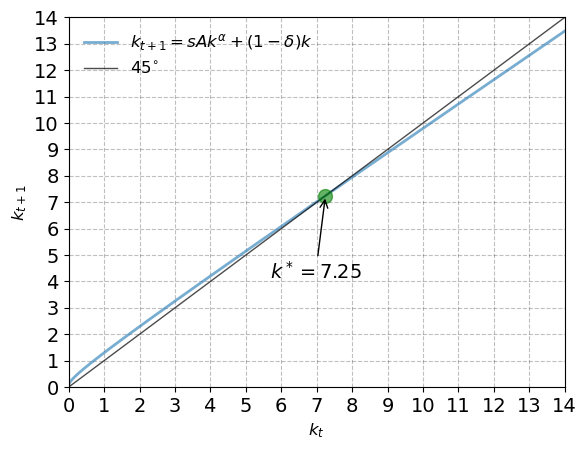

In [5]:
model = Solow_model()
model.plot45()

## 1.3 <a id='toc1_3_'></a>   [Analysis - Simulation and Comparative Analysis](#toc0_)
We want to look further into the dynamics of our model by comparing it with the theoretical dynamics



### 1.3.1. <a id='toc1_3_1_'></a>   [Different Initial Levels of Capital](#toc0_)

We will now show the capital paths for three distinct initial capital levels.

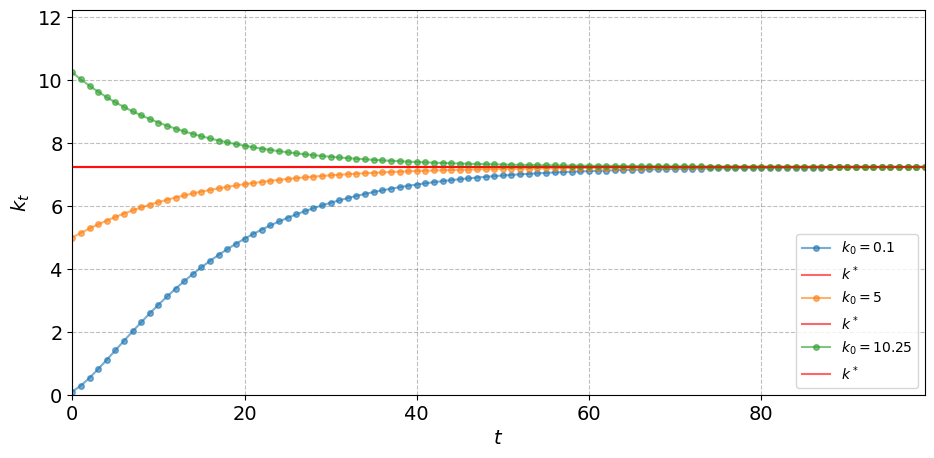

In [6]:
k_ini_values = np.array([0.1, 5, 10.25])
model.simulate(k_ini_values)

We see that for all initial levels of capital, the capital accumulation will converge towards the steady state level k*.


### 1.3.2. <a id='toc1_3_2_'></a>   [Different Savings Rates](#toc0_)
We now look at how different savings rates affect the steady state of capital. We test that our model follows the theoretically positive relationship.

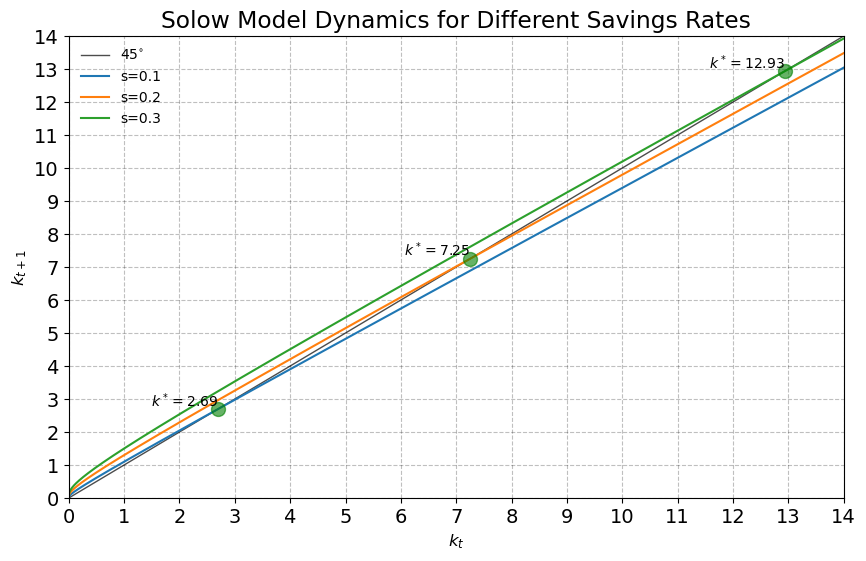

In [7]:
newmodel_combined = Solow_model()
newmodel_combined.plot_combined([0.1, 0.2, 0.3])

We can see that our model corroporates the theoretical relationship.


### 1.3.3. <a id='toc1_3_3_'></a>   [A Shock to Technology](#toc0_)
We now simulate an upwards shock to technology in our model to check if it matches a theoretical shock, where steady state of capital with permanently increase.  

The steady state for k is 7.24578931411126
The steady state for k is 9.966176578193432


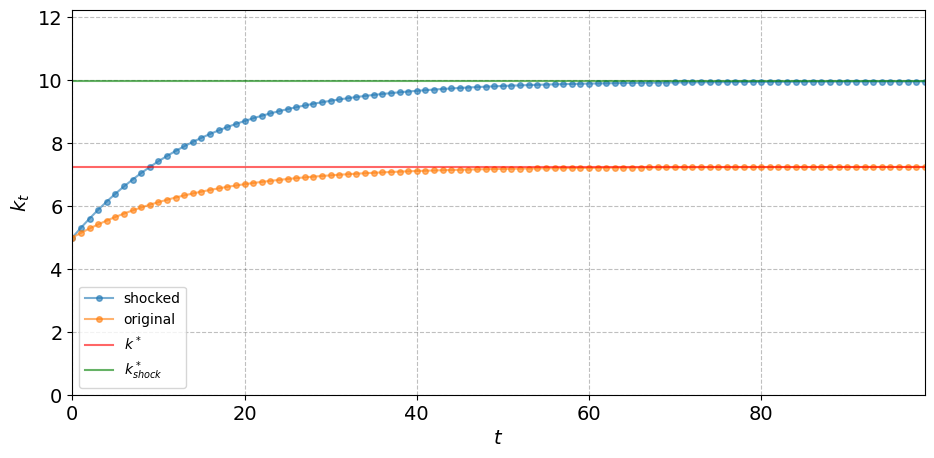

In [8]:
# Create an instance of Solow_model
newmodel = Solow_model()

# Set the shock to A
newmodel.A = 2.5
for i in range(0, 100):
    newmodel.newA[i] = 2.5

# Plot the combined graph before and after the technology shock
newmodel.plot_technology_shock_combined()

We find that our model coorporates with the theoretical model. 


## 2. <a id='toc2_'></a>   [Extensions of the Model](#toc0_)


## 2.1. <a id='toc2_1_'></a>   [Solow Model with Endogenous Technological Progress](#toc0_)

It seems like the technological level in the economy has great importance to the capital accumulation on the long run. That was one of the conclusions from looking at the standard Solow Model where the technology is exogenously given. \
Now, we consider an extension to the standard Solow model by endogenizing the technological.\
It gives us the Solow model with semi-endogenous technological progress:

$$
Y_{t}=K_{t}^\alpha (A_{t}L_{t})^{(1-\alpha)}
$$

$$
A_{t}=K_{t}^{\phi}
$$

$$
K_{t+1}=sY_{t}+(1-\delta)K_{t}
$$

$$
L_{t+1}=(1+n)L_{t}
$$

We look at the model in *per effective worker* terms. I.e., we consider variables as:

$$
\tilde k_{t}=\frac{K_{t}}{A_{t}L_{t}}
$$

and likewise for other variables.

This implies that the production function is given by:

$$
\tilde y_{t}=\tilde k_{t}^\alpha
$$

And the capital accumulation equation is given by:

$$
\tilde k_{t+1} = \frac {1}{(1+n)} \tilde k_{t} [s \tilde k_{t}^{\alpha - 1} + (1-\delta)]^{1-\phi}
$$

*The semi-endogenous technological progress means that some aspects of the technological progress are endogenous (influenced by economic variables and decisions within the model itself).*

### 2.1.1. <a id='toc2_1_1_'></a>   [Analytical Solution](#toc0_)

In [9]:
SolowModel.Solow_chap8_analytical()

Steady-state value of k:


((delta - 1 + (n + 1)**(-1/(phi - 1)))/s)**(1/(alpha - 1))

Substituting the steady-state value of k into the SS equation for y yields the following steady-state value of y:


(((delta - 1 + (n + 1)**(-1/(phi - 1)))/s)**(1/(alpha - 1)))**alpha

These are the same steady state equations that we know from the book "Introducing Advanced Macroeconomics: Growth and Business Cycles".


### 2.1.2. <a id='toc2_1_2_'></a>   [Numerical Solution](#toc0_)

In [10]:
TechModel=SolowModelWithTechProgress()

steady_state_k=TechModel.find_steady_state()
print(f"Steady state values of (k,y) are: {steady_state_k}")

Steady state values of (k,y) are: (2.0720965289851527, 1.244293965655597)


### 2.1.3. <a id='toc2_1_3_'></a>   [Simulation of the Solow model with technological progress](#toc0_)

Now, we will plot the transition equation of the Solow model with endogenous technological progress to understand the dynamics of the capital accumulation:

/Users/agnetenielsen/projects-2024-agnete-og-andrea-12/modelproject/SolowModel.py:336: RuntimeWarning: divide by zero encountered in power
  return (1 / (1 + self.n)) * k * (self.s * k**(self.alpha - 1) + (1 - self.delta))**(1 - self.phi)
/Users/agnetenielsen/projects-2024-agnete-og-andrea-12/modelproject/SolowModel.py:336: RuntimeWarning: invalid value encountered in multiply
  return (1 / (1 + self.n)) * k * (self.s * k**(self.alpha - 1) + (1 - self.delta))**(1 - self.phi)


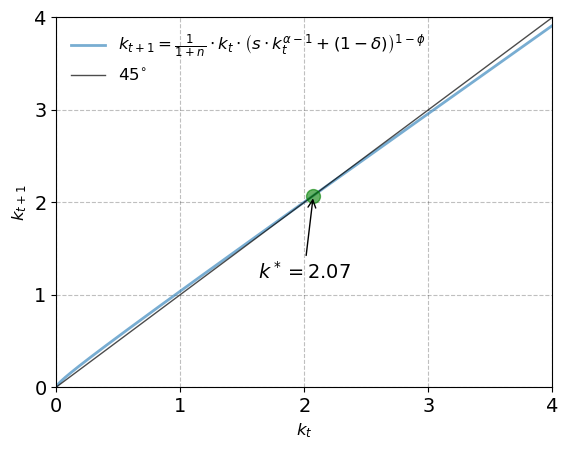

In [11]:
TechModel=SolowModelWithTechProgress()
TechModel.plot45()

The plot shows that the capital is converging towards a steady state.


### 2.1.4. <a id='toc2_1_4_'></a>   [Different initial values of capital](#toc0_)

We will now look into how the transition paths of capital look for different initial values of capital accumulation.

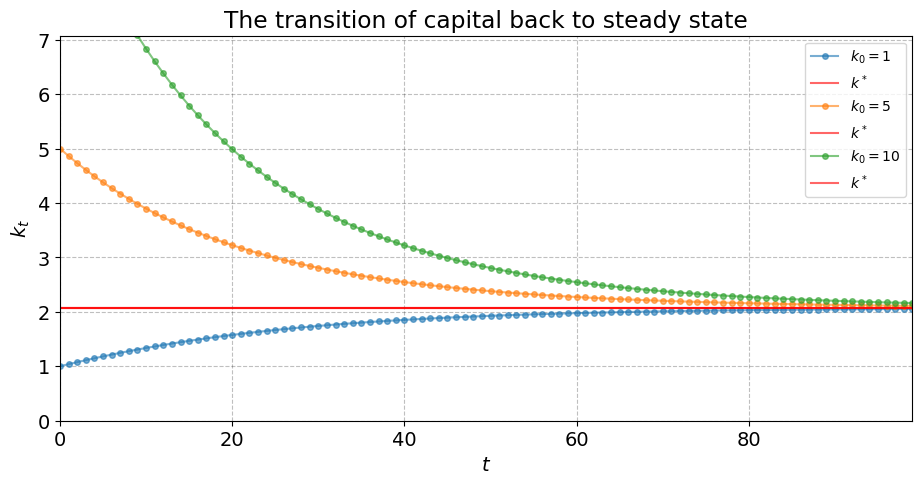

In [12]:
# Simulate and plot the transition of capital for different initial values
TechModel=SolowModelWithTechProgress()
initial_capitals = [1, 5, 10]
TechModel.simulate(initial_capitals)

As expected, all the transition paths (no matter the initial value of capital) converge towards $k^*$.

### 2.1.5. <a id='toc2_1_5_'></a>   [Different Savings Rates](#toc0_)


Now, we will investigate how the savings rate affects the steady state value of capital.

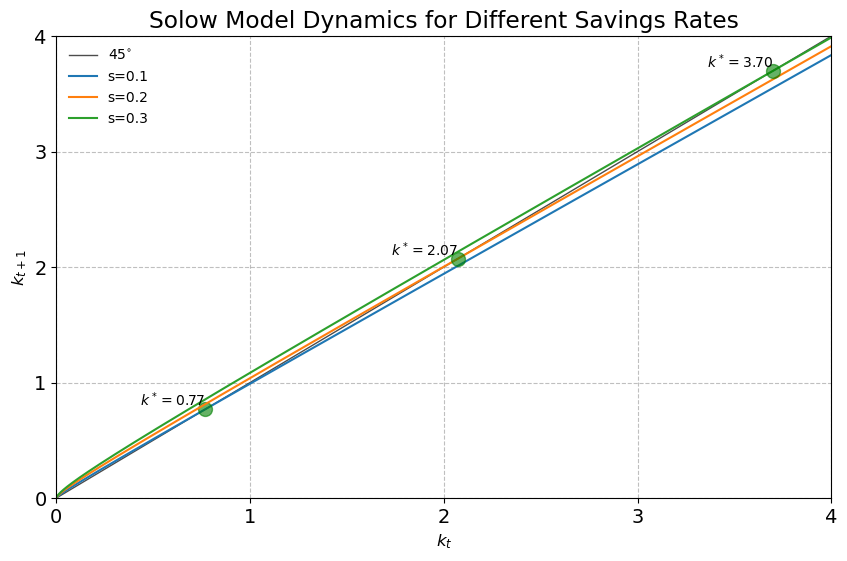

In [13]:
# Plot combined effects for different savings rates
savings_rates = [0.1, 0.2, 0.3]
TechModel.plot_combined(savings_rates)

The figure shows that the higher the savings rate is, the higher level of steady state capital accumulation.

### 2.1.6. <a id='toc2_1_6_'></a>   [A Shock to Technology](#toc0_)

Even though, we have endogenized some of the technological progress, it is still interesting to make a shock to the exogenous part of the technology.

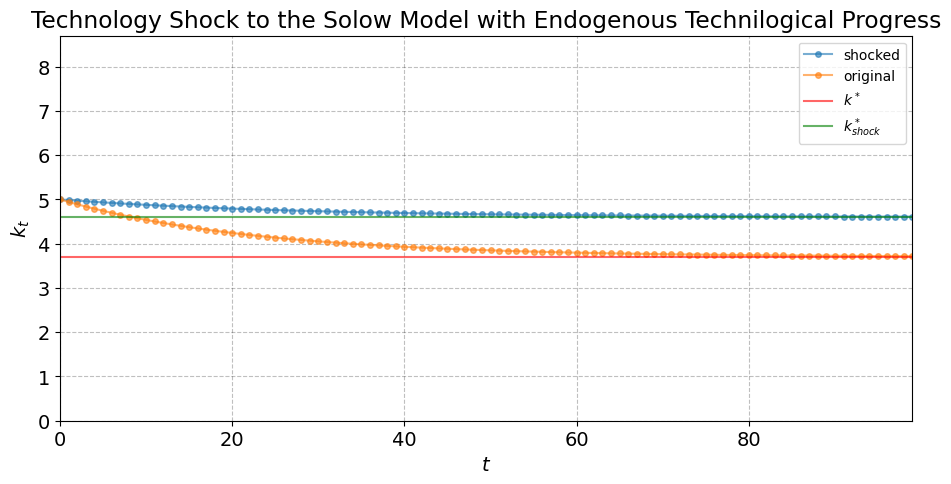

In [14]:
# Plot combined effects of technology shocks
TechModel.plot_technology_shock_combined()


## 2.2. <a id='toc2_2_'></a>   [The Solow Model with Human Capital](#toc0_)


Now, we create an extension of the classic Solow model that includes human capital in the production function. 

The model equations:

$$
Y_t = K_t ^\alpha H_t ^\phi (A_t*L_t)^{(1-\alpha-\phi)}
$$

The technology adjusted variables:
$$
\tilde{y} _t = \tilde{k} _t ^\alpha  \tilde{h}_t ^\phi
$$

The technology adjusted capital accumulation equations:

$$
\tilde{k}_{t+1}=\frac{1}{(1+n)(1+g)} (s_K \tilde{y}_t +(1-\delta)\tilde{k}_t)
$$

$$
\tilde {h}_{t+1}=\frac{1}{(1+n)(1+g)} (s_H \tilde{y}_t +(1-\delta)\tilde{h}_t)
$$

Inserting the equation for $\tilde{y}_t$ yields:
$$
\tilde{k}_{t+1}=\frac{1}{(1+n)(1+g)} (s_K\tilde{k} _t ^\alpha  \tilde{h}_t ^\phi +(1-\delta)\tilde{k}_t)
$$

$$
\tilde {h}_{t+1}=\frac{1}{(1+n)(1+g)} (s_H \tilde{k} _t ^\alpha  \tilde{h}_t ^\phi +(1-\delta)\tilde{h}_t)
$$


### 2.2.1. <a id='toc2_2_1_'></a>   [Analytical Solution](#toc0_)

In [15]:
SolowModel.SolowHuman_analytical_capital()

The steady state equation for k is:


((delta + g*n + g + n)/(h**phi*s_k))**(1/(alpha - 1))

In [16]:
SolowModel.SolowHuman_analytical_humancapital()

The steady state equation for h is:


((delta + g*n + g + n)/(k**alpha*s_h))**(1/(phi - 1))

Now, we want to combine the SS values. I.e. use the SS value of human capital in the SS equation for physical capital. We do this by substituting the SS value of human capital into the SS capital equation and isolate k. After that, we can insert the expression for $k^*$ in the steady state equation for h. Thereby, we will have a SS value for both human capital and physical capital.

In [17]:
SolowModel.SolowHuman_analytical_combined_test()


The combined steady state equation for k is:


((delta + g*n + g + n)/(s_k*(((delta + g*n + g + n)/(k**alpha*s_h))**(1/(phi - 1)))**phi))**(1/(alpha - 1))

The combined steady state equation for h is:


((delta + g*n + g + n)/(s_h*(((delta + g*n + g + n)/(h**phi*s_k))**(1/(alpha - 1)))**alpha))**(1/(phi - 1))

[]

[]

We didn't manage to get the analytical steady state values for H and K as equations that don't depend on the two variables. 


### 2.2.2. <a id='toc2_2_2_'></a>   [Numerical solution and simulation of the Solow model with human capital](#toc0_)
We simulate the model by first finding the steady state values and then plot the phase diagram that shows the transition paths of human capital and physical capital.

Since we didn't succeed in finding the analytical solution in our code, we use the analytical solutions that are given in the book "Introducing Advanced Macroeconomics: Growth and Business Cycles". 

In this book, the steady state values for physical capital and human capital are given by:
$$
\tilde{k}^*=[\frac{(s_K^{1-\phi}*s_H^{\phi})}{(n+g+\delta+ng))}]^{1/(1-\alpha-\phi)}
$$
$$
\tilde{h}^*=[\frac{(s_K^{\alpha}*s_H^{1-\alpha})}{(n+g+\delta+ng))}]^{1/(1-\alpha-\phi)}
$$

We use these values in our further analysis.

In [18]:
model = SolowModelwithHumanCapital()

Steady-state value for capital (k*): 2.0292043084065865
Steady-state value for human capital (h*): 2.0292043084065883


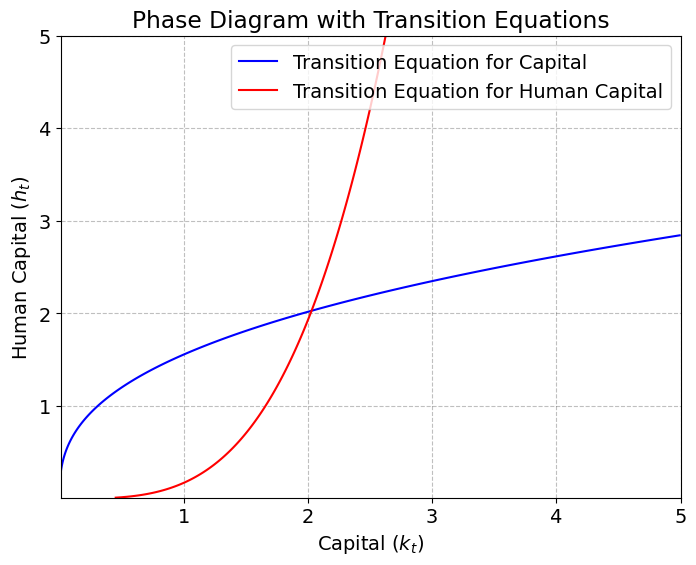

In [19]:
model.run()
model.plot_phase_diagram_transition_equations()

The phase diagram shows the steady state at (2.03, 2.03).



## 3. <a id='toc3_'></a>   [Conclusion](#toc0_)

The classic Solow Growth Model performs well under simulation and converges towards a steady state of capital. Under further analysis we show that our model coorporates with the wellknown  dynamics of the theoretical model. 

The extension of the model also shows convergence for both capital and human capital. The steady state value for capital is lower when including human capital, which does not comply with theory. This suggests an error in our extension.